In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from collections import Counter
import pywt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from scipy.stats import skew, kurtosis,entropy
from sklearn.preprocessing import MinMaxScaler
from scipy.fftpack import fft, fftfreq
from sklearn.metrics import classification_report,confusion_matrix
from scipy.fft import fft, fftfreq

In [25]:
data1=pd.read_csv("C:\\Users\\bhuni\\Downloads\\ECG (2_1).csv")
data1=data1.fillna(0)
data1

,time,mV
0,2025 06 26 11:42:14.431748,339
1,0,611
2,0,919
3,0,575
4,0,563
...,...,...
354559,0,1114
354560,0,1094
354561,0,1136
354562,0,1119


In [27]:
ecg_signal1=data1.iloc[0:354564,1:2] .values.ravel()
ecg_signal1
ecg_signal1.shape

(354564,)

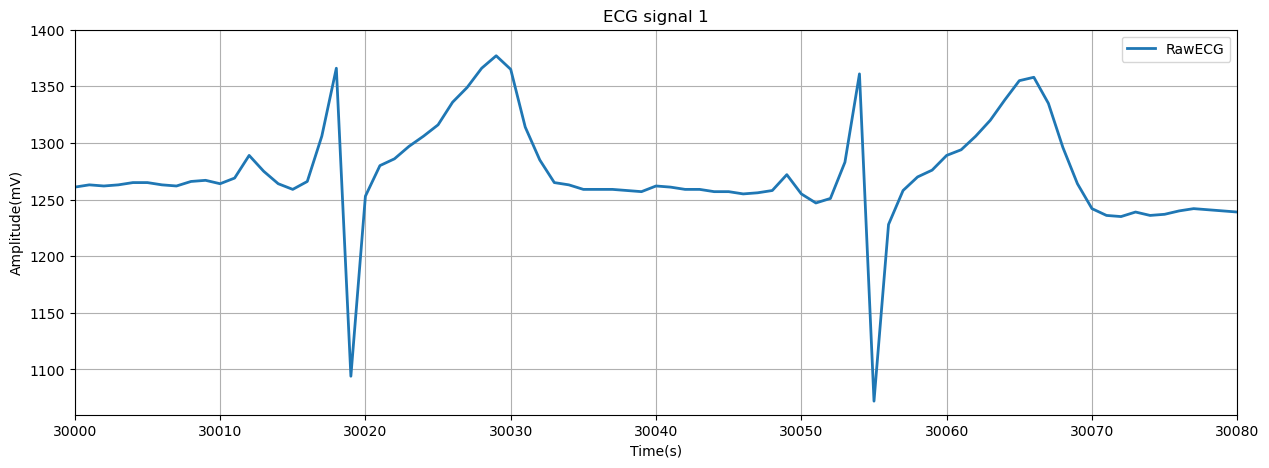

In [29]:
plt.figure(figsize=(15,5))
plt.plot(ecg_signal1,linewidth=2,label='RawECG')
plt.xlabel('Time(s)')
plt.ylabel('Amplitude(mV)')
plt.title('ECG signal 1')
#plt.xlim([20000,20200])
#plt.ylim([1000,1500])
plt.xlim([30000,30080])
plt.ylim([1060,1400])
plt.grid(True)
plt.legend()
plt.show()

In [31]:
data2=pd.read_csv("C:\\Users\\bhuni\\Downloads\\ECG (2_2).csv")
data2=data2.fillna(0)
data2

,time,mV
0,2025 06 26 11:42:14.431748,339
1,0,611
2,0,919
3,0,575
4,0,563
...,...,...
365871,0,694
365872,0,693
365873,0,693
365874,0,694


In [33]:
ecg_signal2=data2.iloc[0:365876,1:2] .values.ravel()
ecg_signal2
ecg_signal2.shape

(365876,)

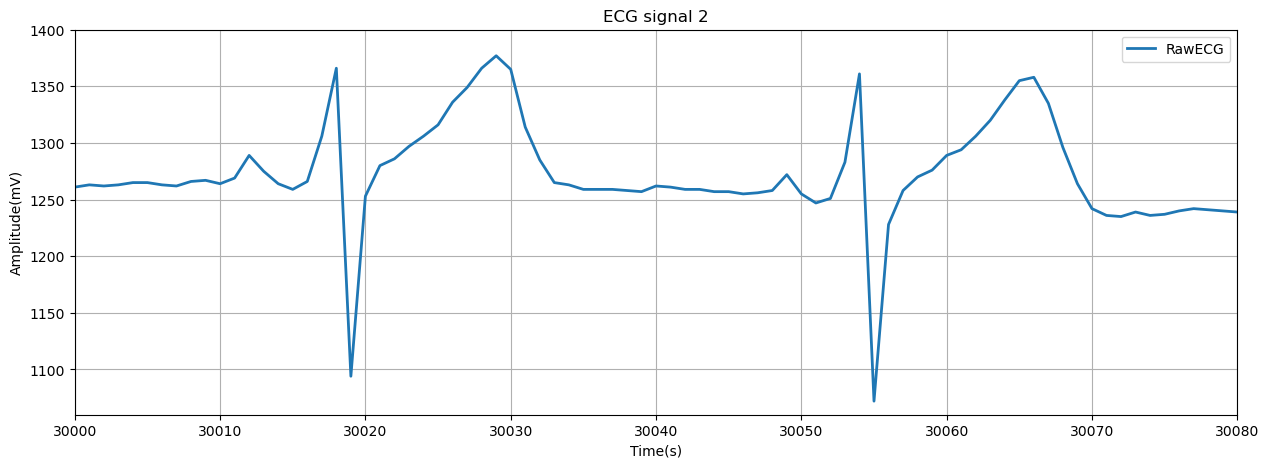

In [37]:
plt.figure(figsize=(15,5))
plt.plot(ecg_signal2,linewidth=2,label='RawECG')
plt.xlabel('Time(s)')
plt.ylabel('Amplitude(mV)')
plt.title('ECG signal 2')
#plt.xlim([20000,20200])
#plt.ylim([1000,1500])
plt.xlim([30000,30080])
plt.ylim([1060,1400])
plt.grid(True)
plt.legend()
plt.show()

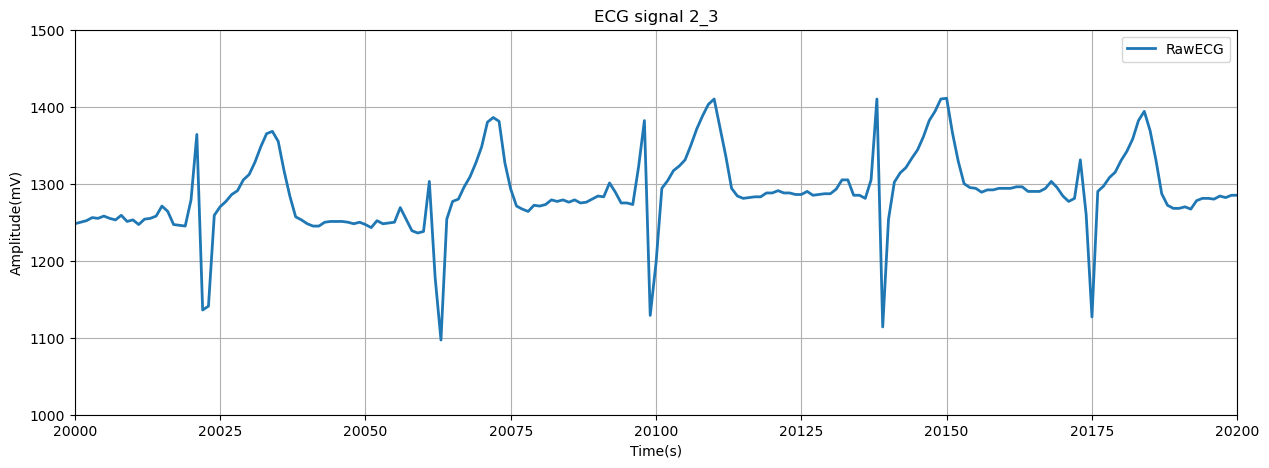

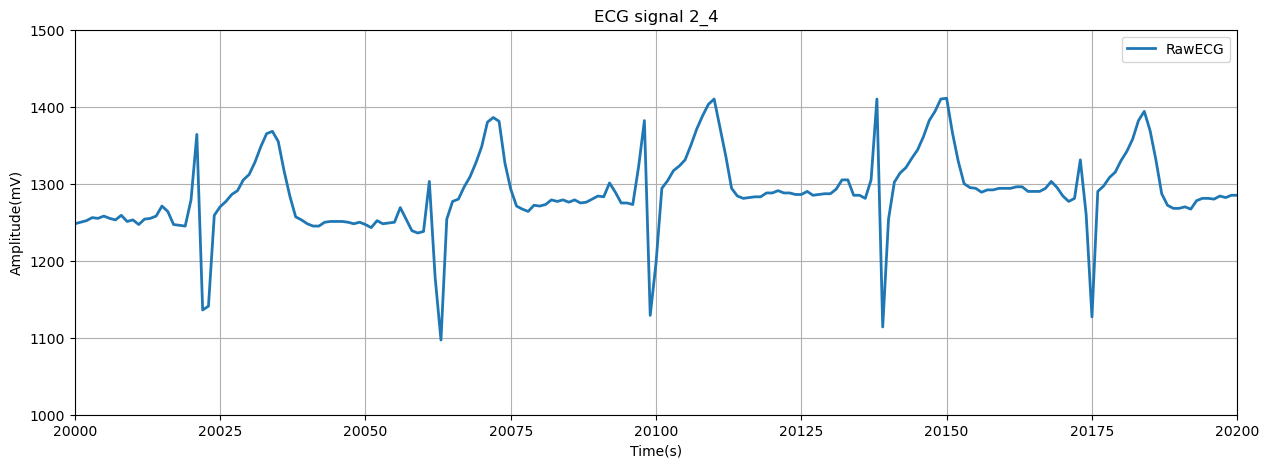

,time,mV
0,2025 06 26 11:42:14.431748,339
1,0,611
2,0,919
3,0,575
4,0,563
...,...,...
393507,0,308
393508,0,309
393509,0,313
393510,0,322


In [193]:
data3=pd.read_csv("C:\\Users\\bhuni\\Downloads\\ECG (2_3).csv")
data3=data3.fillna(0)
data3
ecg_signal3=data3.iloc[0:354563,1:2] .values.ravel()
ecg_signal3
ecg_signal3.shape
plt.figure(figsize=(15,5))
plt.plot(ecg_signal2,linewidth=2,label='RawECG')
plt.xlabel('Time(s)')
plt.ylabel('Amplitude(mV)')
plt.title('ECG signal 2_3')
plt.xlim([20000,20200])
plt.ylim([1000,1500])
plt.grid(True)
plt.legend()
plt.show()

data4=pd.read_csv("C:\\Users\\bhuni\\Downloads\\ECG (2_4).csv")
data4=data4.fillna(0)
data4
ecg_signal4=data4.iloc[0:354563,1:2] .values.ravel()
ecg_signal4
ecg_signal4.shape
plt.figure(figsize=(15,5))
plt.plot(ecg_signal2,linewidth=2,label='RawECG')
plt.xlabel('Time(s)')
plt.ylabel('Amplitude(mV)')
plt.title('ECG signal 2_4')
plt.xlim([20000,20200])
plt.ylim([1000,1500])
plt.grid(True)
plt.legend()
plt.show()

data5=pd.read_csv("C:\\Users\\bhuni\\Downloads\\ECG (2_5).csv")
data5=data5.fillna(0)
data5

In [194]:
ecg_signal5=data5.iloc[0:393512,1:2] .values.ravel()
ecg_signal5
ecg_signal5.shape

(393512,)

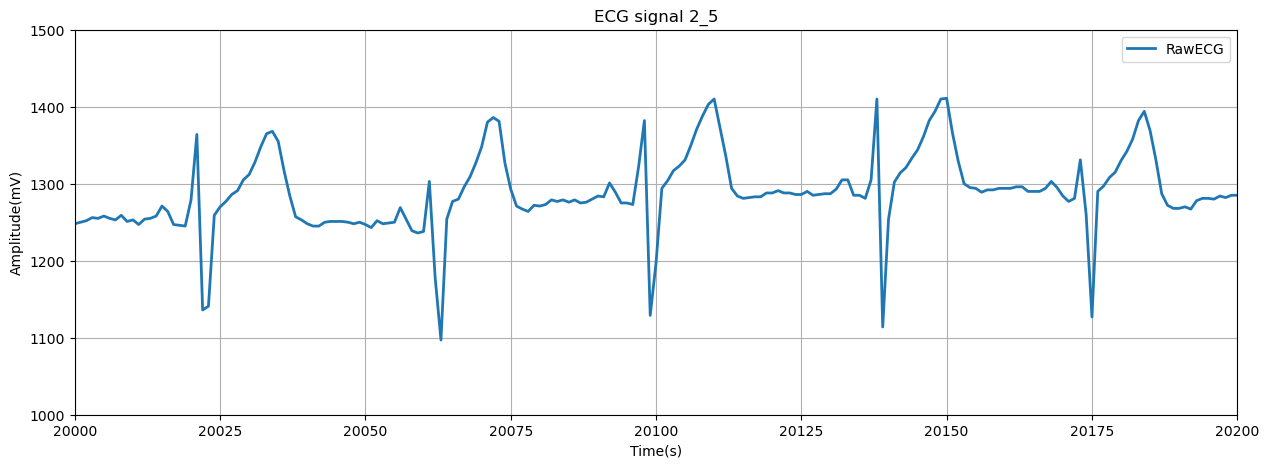

In [197]:
plt.figure(figsize=(15,5))
plt.plot(ecg_signal5,linewidth=2,label='RawECG')
plt.xlabel('Time(s)')
plt.ylabel('Amplitude(mV)')
plt.title('ECG signal 2_5')
plt.xlim([20000,20200])
plt.ylim([1000,1500])
plt.grid(True)
plt.legend()
plt.show()

In [199]:
#Removing DC Offset From Signal data_no_outlier_3 
data_1=data1.mV-np.mean(data1.mV)
data_1

0        -567.05777
1        -295.05777
2          12.94223
3        -331.05777
4        -343.05777
            ...    
354559    207.94223
354560    187.94223
354561    229.94223
354562    212.94223
354563    216.94223
Name: mV, Length: 354564, dtype: float64

In [201]:
data_4=data4.mV-np.mean(data4.mV)
data_4

0        -542.00897
1        -270.00897
2          37.99103
3        -306.00897
4        -318.00897
            ...    
383483   -251.00897
383484   -254.00897
383485   -276.00897
383486   -301.00897
383487   -318.00897
Name: mV, Length: 383488, dtype: float64

In [203]:
data_5=data5.mV-np.mean(data5.mV)
data_5

0        -527.883058
1        -255.883058
2          52.116942
3        -291.883058
4        -303.883058
             ...    
393507   -558.883058
393508   -557.883058
393509   -553.883058
393510   -544.883058
393511   -546.883058
Name: mV, Length: 393512, dtype: float64

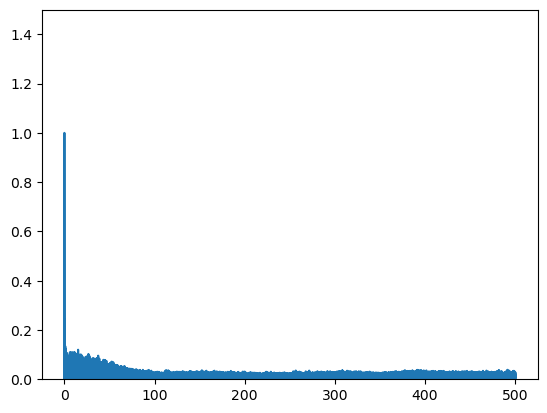

In [205]:
#FFT
from scipy.fftpack import fft,fftfreq
#data_no_outlier_5=data.iloc[5:6,1:2501].values.ravel()
#plt.figure(figsize=(10,2))
fs=1000 #sampling frequency
t=np.arange(len(data_5.values))/fs
N=len(data_5.values)
fft_clean=fft(data_5.values)
freqs=fftfreq(N,1/fs)

#focus on positive frequencies
pos_freqs_clean=freqs[:N//2]
magnitude_clean=np.abs(fft_clean[:N//2])
magnitude_clean_norm=(magnitude_clean-np.min(magnitude_clean))/(np.max(magnitude_clean)-np.min(magnitude_clean))
plt.plot(pos_freqs_clean,magnitude_clean_norm)
#plt.xlim([40,50])
plt.ylim([0,1.5])         
plt.show()

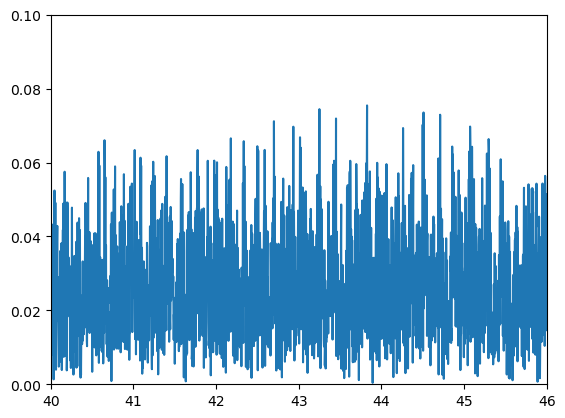

In [207]:
t=np.arange(len(data_4.values))/fs
N=len(data_4.values)
fft_clean=fft(data_4.values)
freqs=fftfreq(N,1/fs)

#focus on positive frequencies
pos_freqs_clean=freqs[:N//2]
magnitude_clean=np.abs(fft_clean[:N//2])
magnitude_clean_norm=(magnitude_clean-np.min(magnitude_clean))/(np.max(magnitude_clean)-np.min(magnitude_clean))
plt.plot(pos_freqs_clean,magnitude_clean_norm)
plt.xlim([40,46])
plt.ylim([0,0.1])         
plt.show()

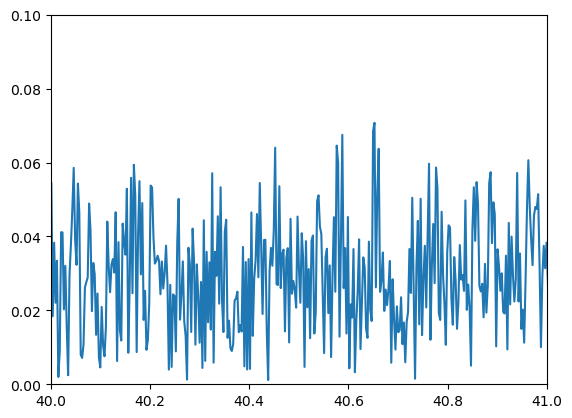

In [209]:
t=np.arange(len(data_1.values))/fs
N=len(data_1.values)
fft_clean=fft(data_1.values)
freqs=fftfreq(N,1/fs)

#focus on positive frequencies
pos_freqs_clean=freqs[:N//2]
magnitude_clean=np.abs(fft_clean[:N//2])
magnitude_clean_norm=(magnitude_clean-np.min(magnitude_clean))/(np.max(magnitude_clean)-np.min(magnitude_clean))
plt.plot(pos_freqs_clean,magnitude_clean_norm)
plt.xlim([40,41])
plt.ylim([0,0.1])         
plt.show()

In [211]:
from scipy import signal
import matplotlib.pyplot as plt

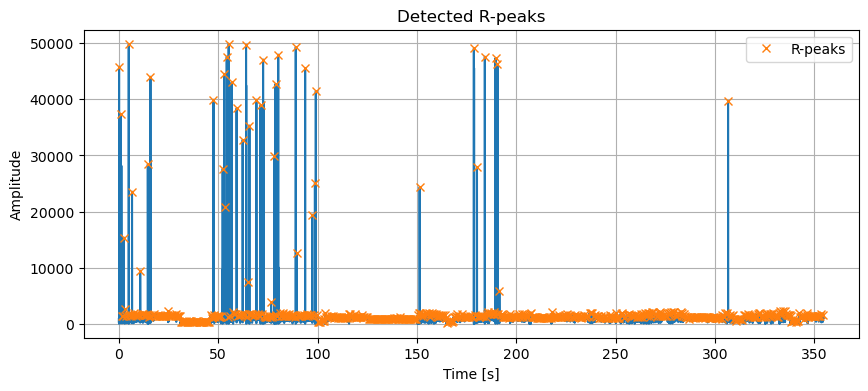

In [213]:
peaks, _ = signal.find_peaks(ecg_signal1, distance=fs/2.5, height=0.5)

plt.figure(figsize=(10, 4))
plt.plot(t, ecg_signal1)
plt.plot(t[peaks], ecg_signal1[peaks], "x", label='R-peaks')
plt.title("Detected R-peaks")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
#plt.xlim([0,100])
#plt.ylim([60,1700])
plt.grid(True)
plt.legend()
plt.show()

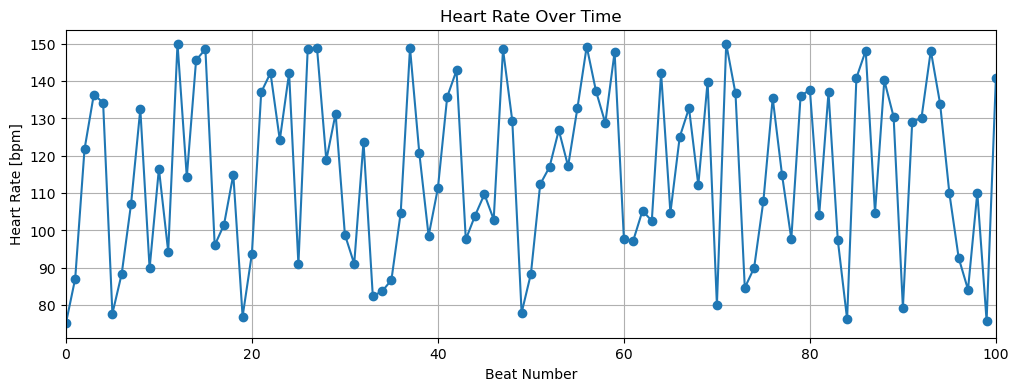

In [215]:
import numpy as np
rr_intervals = np.diff(t[peaks])  # Time between peaks
heart_rate = 60 / rr_intervals    # Beats per minute (bpm)

plt.figure(figsize=(12, 4))
plt.plot(heart_rate, marker='o')
plt.title("Heart Rate Over Time")
plt.xlabel("Beat Number")
plt.ylabel("Heart Rate [bpm]")
plt.xlim([0,100])
#plt.ylim([80,100])
plt.grid(True)
plt.show()

In [217]:
from scipy.signal import find_peaks

# Step 1: Detect R-peaks
#peaks, _ = find_peaks(ecg_signal, distance=fs*0.6)  # fs = sampling frequency

# Step 2: Calculate time between successive R-peaks
#rr_intervals = np.diff(t[peaks])  # in seconds

# Step 3: (Optional) Compute heart rate in bpm
#heart_rate = 60 / rr_intervals

# Print
for i, rr in enumerate(rr_intervals):
    print(f"RR interval {i+1}: {rr:.3f} seconds -> Heart rate: {60/rr:.2f} bpm")

RR interval 1: 0.799 seconds -> Heart rate: 75.09 bpm
RR interval 2: 0.689 seconds -> Heart rate: 87.08 bpm
RR interval 3: 0.493 seconds -> Heart rate: 121.70 bpm
RR interval 4: 0.440 seconds -> Heart rate: 136.36 bpm
RR interval 5: 0.447 seconds -> Heart rate: 134.23 bpm
RR interval 6: 0.772 seconds -> Heart rate: 77.72 bpm
RR interval 7: 0.679 seconds -> Heart rate: 88.37 bpm
RR interval 8: 0.561 seconds -> Heart rate: 106.95 bpm
RR interval 9: 0.453 seconds -> Heart rate: 132.45 bpm
RR interval 10: 0.668 seconds -> Heart rate: 89.82 bpm
RR interval 11: 0.515 seconds -> Heart rate: 116.50 bpm
RR interval 12: 0.636 seconds -> Heart rate: 94.34 bpm
RR interval 13: 0.400 seconds -> Heart rate: 150.00 bpm
RR interval 14: 0.525 seconds -> Heart rate: 114.29 bpm
RR interval 15: 0.412 seconds -> Heart rate: 145.63 bpm
RR interval 16: 0.404 seconds -> Heart rate: 148.51 bpm
RR interval 17: 0.625 seconds -> Heart rate: 96.00 bpm
RR interval 18: 0.591 seconds -> Heart rate: 101.52 bpm
RR inter

In [219]:
duration_seconds = len(ecg_signal1) / fs     # Total signal duration in seconds
duration_minutes = duration_seconds / 60      # Convert to minutes

average_heart_rate = len(peaks) / duration_minutes

print(f"Average Heart Rate: {average_heart_rate:.2f} bpm")

Average Heart Rate: 111.35 bpm
